In [1]:
import os
os.chdir("../")
configs_file = "train_debug"

In [2]:
import os
from functools import partial

import equinox as eqx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from corrosion2d.configs import load_configs
configs = load_configs(configs_file).Configs()

# from corrosion2d.configs import Configs
# configs = Configs()

from ggsci import pal_npg, pal_gsea
colors = pal_npg()(10)
import seaborn as sns
from matplotlib import font_manager
font_dir = "./helvetica/"
font_names = os.listdir(font_dir)
for font_name in font_names:
    font_manager.fontManager.addfont(font_dir + font_name)
# nature style
from matplotlib import rcParams
rcParams.update({
    "font.size": 7,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica",],
    "pdf.fonttype": 42,
    "figure.dpi": 300,
    "xtick.direction": "in",
    "ytick.direction": "in",
    # thin ticks
    "xtick.major.width": 0.5,
    "ytick.major.width": 0.5,
    # thin axes
    "axes.linewidth": 0.5,
    # thin legend frame
    "legend.frameon": False,
    # set color_theme as ggsci
    "axes.prop_cycle": plt.cycler(color=[
        "#E64B35", "#4DBBD5", "#00A087",
        "#3C5488", "#F39B7F", "#8491B4",
        "#91D1C2", "#DC0000", "#7E6148", "#B09C85"
    ]),
    # "axes.prop_cycle": plt.cycler(color=colors),
})


Text(0, 0.5, 'Loss')

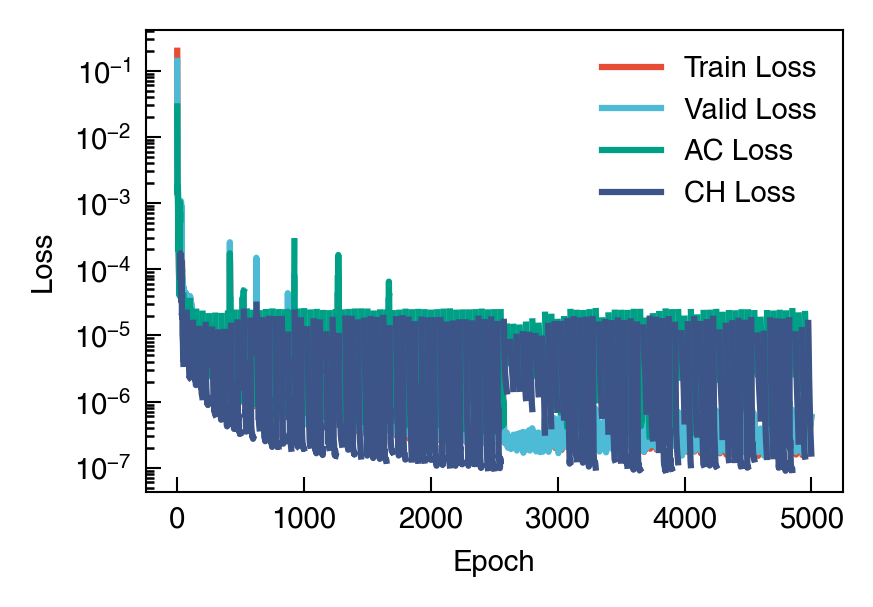

In [3]:
# read csv loss
import pandas as pd
save_dir = configs.save_dir
loss_df = pd.read_csv(os.path.join(save_dir, "logs.csv"))
loss_df = loss_df.sort_values(by="Epoch")
fig, ax = plt.subplots(1, 1, figsize=(3, 2))
ax.plot(loss_df["Epoch"], loss_df["TrainLoss"], label="Train Loss")
ax.plot(loss_df["Epoch"], loss_df["ValidLoss"], label="Valid Loss")
if configs.physical_residual:
    ax.plot(loss_df["Epoch"], loss_df["ACLoss"], label="AC Loss")
    ax.plot(loss_df["Epoch"], loss_df["CHLoss"], label="CH Loss")
ax.legend()
ax.set_yscale("log")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")

Text(0, 0.5, 'MSE')

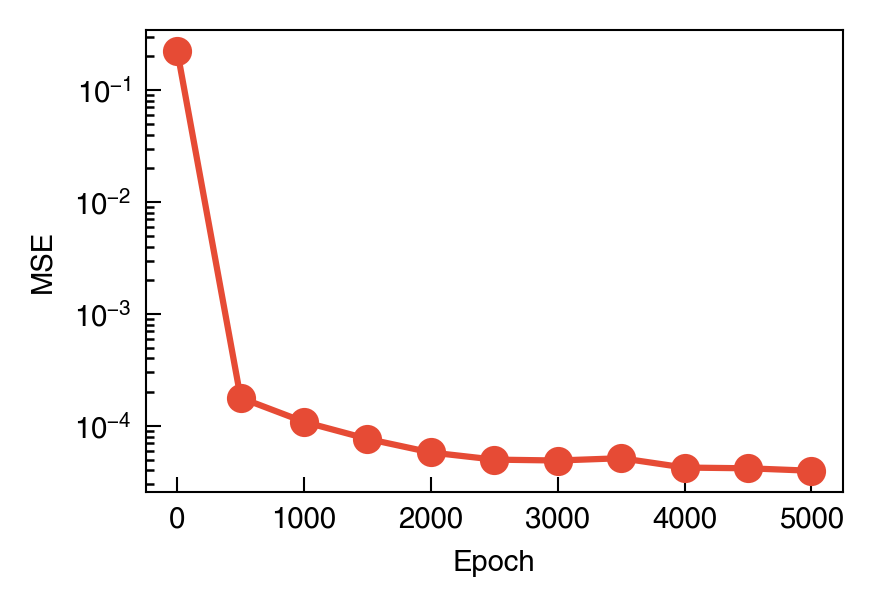

In [4]:
test_mse_df = pd.read_csv(os.path.join(save_dir, "test_logs.csv"))
test_mse_df = test_mse_df.sort_values(by="Epoch")
fig, ax = plt.subplots(1, 1, figsize=(3, 2))
ax.plot(test_mse_df["Epoch"], test_mse_df["TestMSE"], label="Test MSE", marker='o')
ax.set_yscale("log")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE")

In [5]:
# from model import model1d
from corrosion2d.model2d import get_model2d

model_kwargs = {
   'modes_x': configs.modes_x,
   'modes_y': configs.modes_x,
   'width': configs.width,
   'depth': configs.depth,
   'activation': getattr(jax.nn, configs.activation),
   'key': jax.random.PRNGKey(0),
   'inception': configs.inception,
}


model_skeleton = get_model2d(
   configs.model_type,
   configs.in_channels,
   configs.out_channels,
   **model_kwargs
)
# model_skeleton = get_model1d(configs, jax.random.PRNGKey(0))
weight = os.path.join(save_dir, f"epoch_{configs.epochs - 1}.eqx")
# weight = os.path.join(save_dir, f"epoch_4000.eqx")
model = eqx.tree_deserialise_leaves(weight, model_skeleton)

In [6]:
# data = jnp.load("./dataset_split.npz")
data = jnp.load(os.path.join(configs.data_dir, "dataset_split.npz"))

# Xs, Ys = data["train_x"], data["train_y"]
Xs, Ys = data["valid_x"], data["valid_y"]
meshes = jnp.load(os.path.join(configs.data_dir, "dataset_2d_complete.npz"))["meshes"]
times = jnp.load(os.path.join(configs.data_dir, "dataset_2d_complete.npz"))["times"]
dt = times[1] - times[0]
meshes = jnp.transpose(meshes, (2, 0, 1))
meshesx = meshes[0]
meshesy = meshes[1]
Xs.shape, Ys.shape

((250, 5, 51, 101), (250, 2, 51, 101))

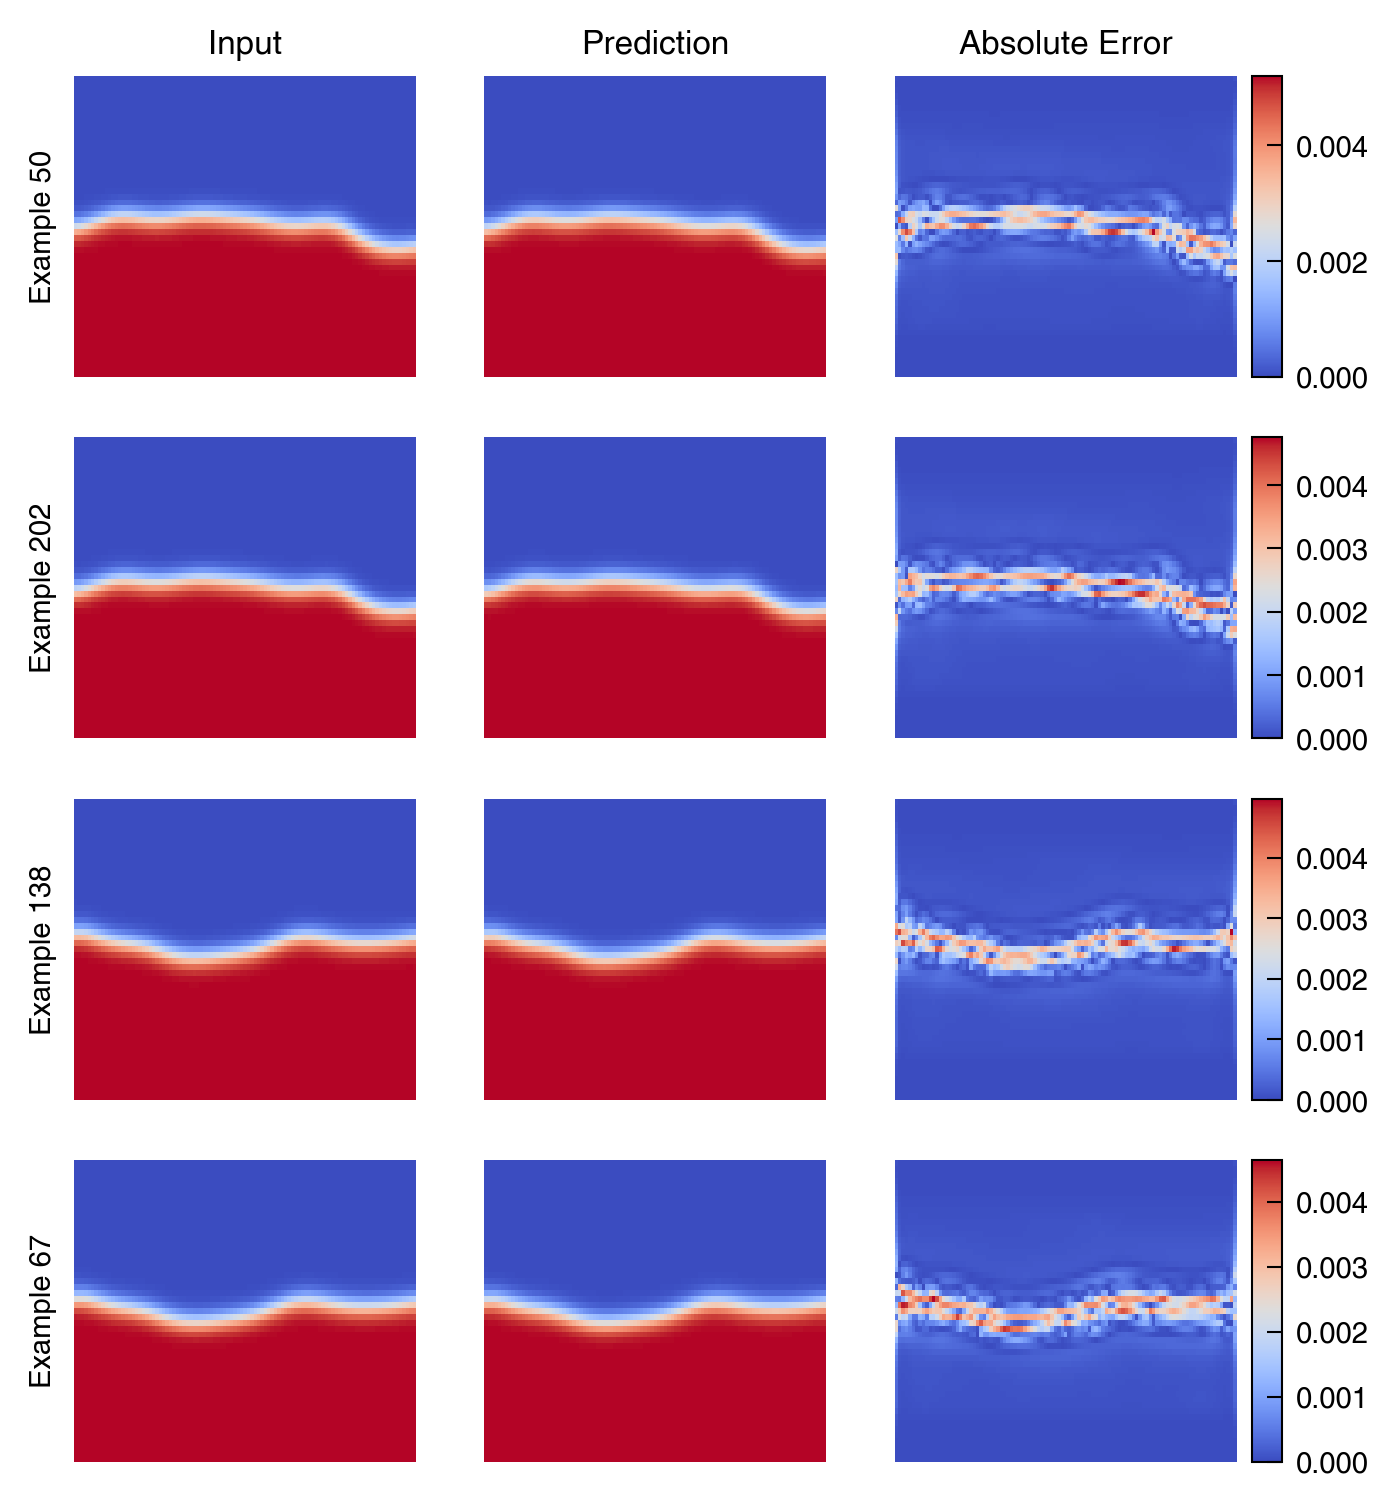

In [7]:
num_examples = 4
import numpy as np
random_indices = np.random.choice(Xs.shape[0], num_examples, replace=False)
fig, axes = plt.subplots(num_examples, 3, figsize=(5, 1.5 * num_examples))
xs_examples = Xs[random_indices]
ys_examples = Ys[random_indices]
y_pred_examples = jax.vmap(model.forward)(xs_examples)

for i, idx in enumerate(random_indices):
    ax = axes[i, 0]
    ax.pcolormesh(meshesx, meshesy, xs_examples[i, 0, :, :], cmap='coolwarm')
    ax.set_axis_off()
    # ax.set_ylabel(f"Example {idx}", rotation=0, labelpad=20, fontsize=8, va='center')
    ax.text(-0.05, 0.5, f"Example {idx}", rotation=90, va='center', ha="right", transform=ax.transAxes,)
    if i == 0:
        ax.text(0.5, 1.05, "Input", ha="center", va="bottom", transform=ax.transAxes, fontsize=8)

    ax = axes[i, 1]
    ax.pcolormesh(meshesx, meshesy, ys_examples[i, 0, :, :],  cmap='coolwarm')
    ax.set_axis_off()
    if i == 0:
        ax.text(0.5, 1.05, "Prediction", ha="center", va="bottom", transform=ax.transAxes, fontsize=8)

    ax = axes[i, 2]
    diff = jnp.abs(ys_examples[i, 0, :, :] - y_pred_examples[i, 0, :, :])
    diff_ax = ax.pcolormesh(meshesx, meshesy, diff,  cmap='coolwarm')
    ax.set_axis_off()
    if i == 0:
        ax.text(0.5, 1.05, "Absolute Error", ha="center", va="bottom", transform=ax.transAxes, fontsize=8)

    ax_bar = fig.add_axes([ax.get_position().x1 + 0.01,
                           ax.get_position().y0,
                           0.02,
                           ax.get_position().height])
    fig.colorbar(diff_ax, cax=ax_bar)
# fig.tight_layout()

In [8]:
test_solutions = jnp.load(os.path.join(configs.test_data_dir, "solutions_grid_initials.npy"))
u0 = test_solutions[:, 0, :, :]
y_test = test_solutions[:, 1:, :, :]
auto_reg_fn = partial(
    model.auto_reg,
    meshes=meshes,
    dt=dt,
    steps=100
)
u_preds = jax.vmap(auto_reg_fn)(u0)  # (num_test, steps, H, W)

In [9]:
y_test.shape

(5, 100, 2, 51, 101)

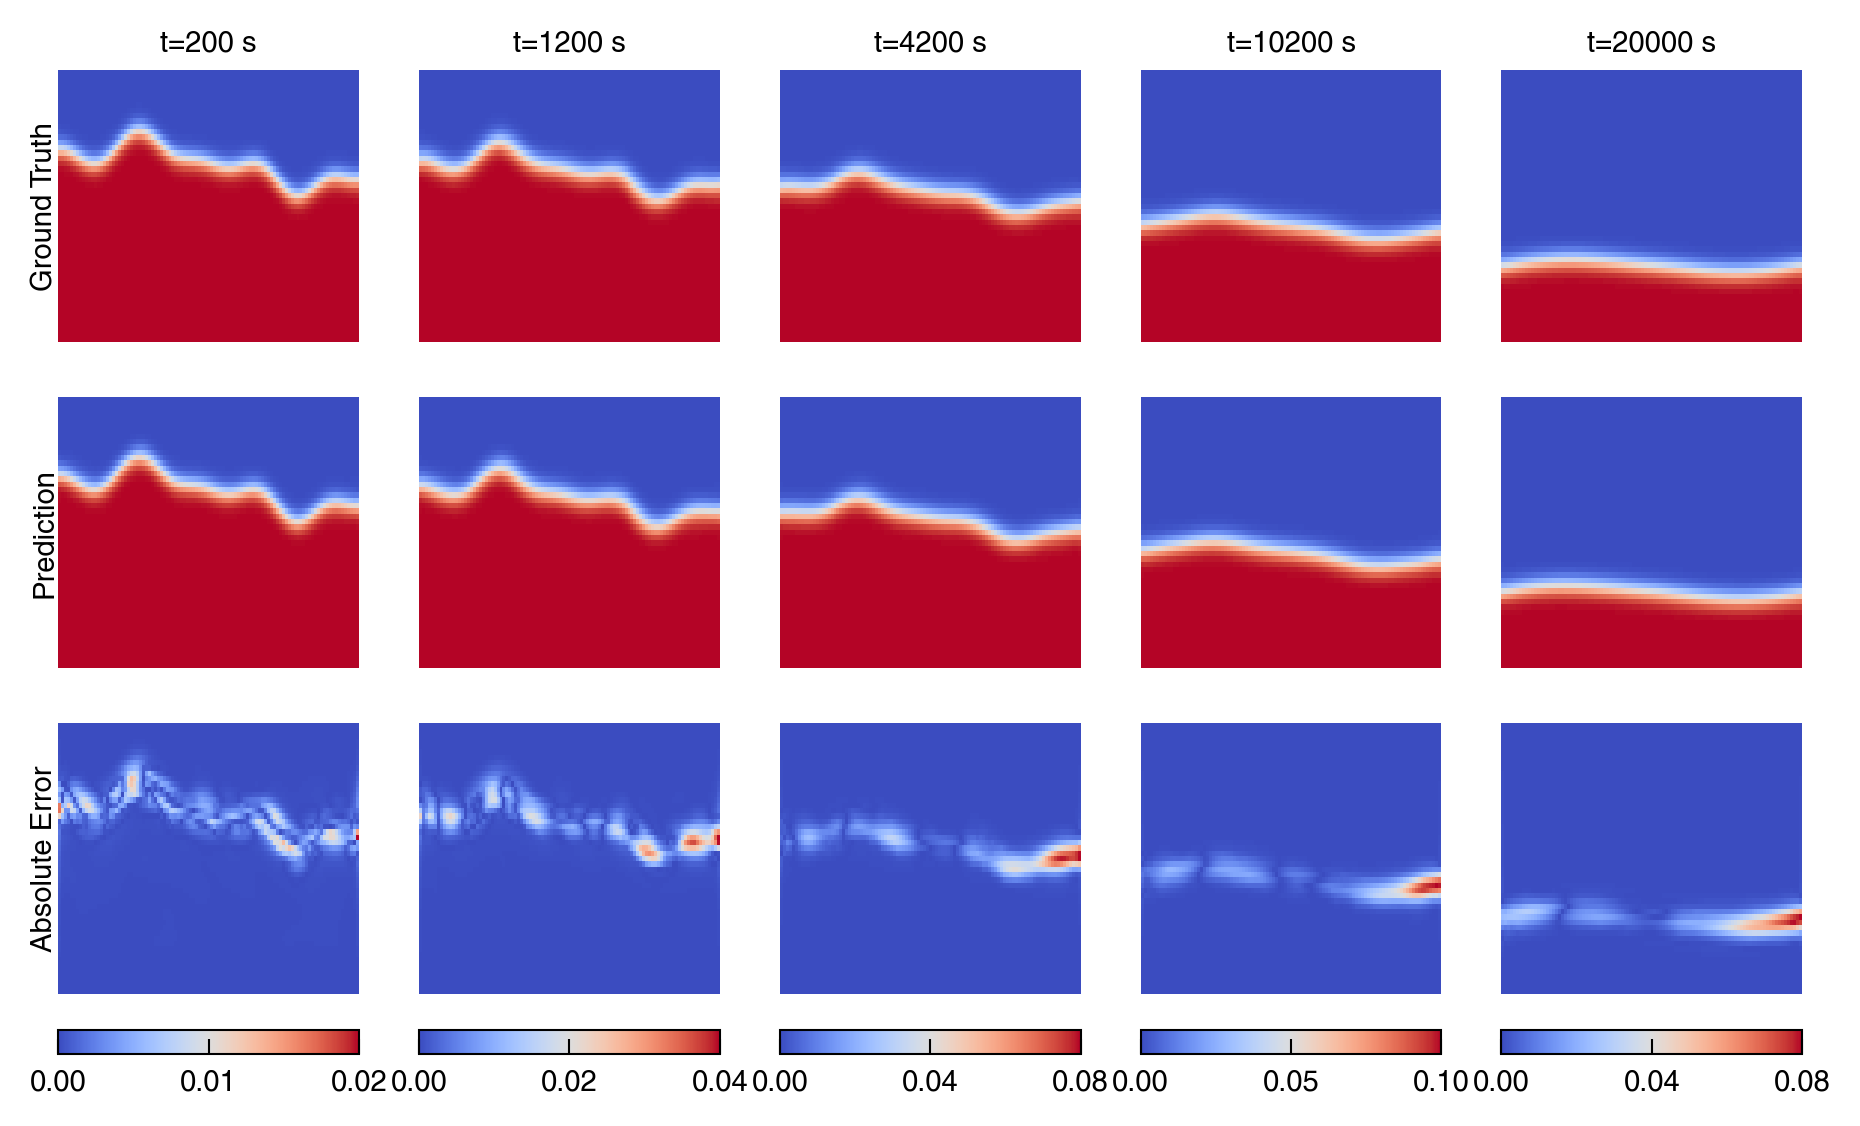

In [14]:
idxs = [0, 5, 20, 50, 99,]
meshesx = meshes[0]
meshesy = meshes[1]
example_th = 2
fig, axes = plt.subplots(3, len(idxs), figsize=(1.5 * len(idxs), 4))
for i, idx in enumerate(idxs):
    ax = axes[0, i]
    ax.pcolormesh(meshesx, meshesy, y_test[example_th, idx, 0, :, :], cmap='coolwarm')
    if i == 0:
        ax.text(0., 0.5, "Ground Truth", ha="right", va="center", transform=ax.transAxes, rotation=90)
    # ax.set_title(f"Ground Truth t={int((idx+1)*dt*configs.Tc)} s")
    ax.set_axis_off()
    ax.text(0.5, 1.05, f"t={int((idx+1)*dt*configs.Tc)} s", ha="center", va="bottom", transform=ax.transAxes)

    ax = axes[1, i]
    ax.pcolormesh(meshesx, meshesy, u_preds[example_th, idx, 0, :, :],  cmap='coolwarm')
    if i == 0:
        ax.text(0., 0.5, "Prediction", ha="right", va="center", transform=ax.transAxes, rotation=90)
    ax.set_axis_off()

    ax = axes[2, i]
    diff = jnp.abs(y_test[example_th, idx, 0, :, :] - u_preds[example_th, idx, 0, :, :])
    diff_ax = ax.pcolormesh(meshesx, meshesy, diff, cmap='coolwarm')
    if i == 0:
        ax.text(0., 0.5, "Absolute Error", ha="right", va="center", transform=ax.transAxes, rotation=90)
    ax.set_axis_off()
    
    # add a ax_bar at the bottom of the figure
    ax_bar = fig.add_axes([ax.get_position().x0,
                           ax.get_position().y0 - 0.05,
                           ax.get_position().width,
                           0.02])
    # fewer ticks on colorbar with 2 precision
    fig.colorbar(diff_ax, cax=ax_bar, orientation='horizontal',
                 format='%.2f', ticks=jnp.linspace(0, jnp.max(diff), num=3))

Text(0, 0.5, 'Mean Absolute Error')

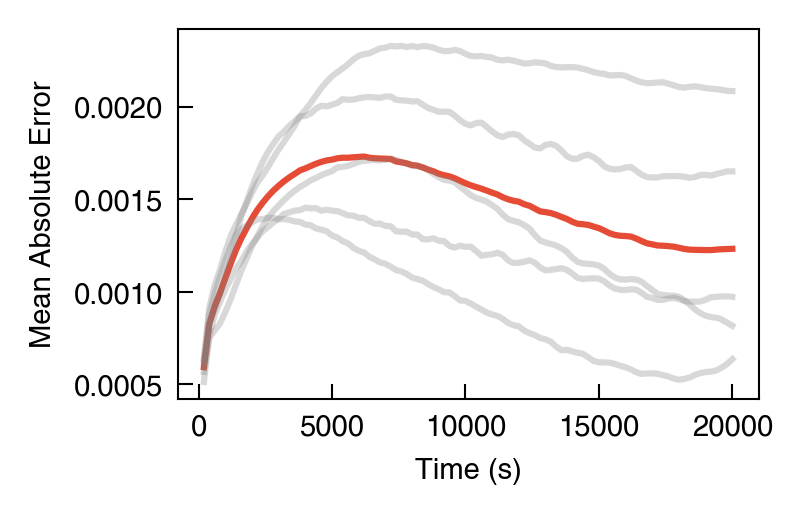

In [11]:
diffs = jnp.abs(y_test[:, :, 0, :, :] - u_preds[:, :, 0, :, :])
diffs = jnp.mean(diffs, axis=(2,3))  # (num_test, num_time_steps)
diffs_avg = jnp.mean(diffs, axis=0)  # (num_time_steps,)
times_plot = times[1:] * configs.Tc
fig, ax = plt.subplots(1, 1, figsize=(2.5, 1.6))
ax.plot(times_plot, diffs_avg)
for i in range(diffs.shape[0]):
    ax.plot(times_plot, diffs[i, :], color='gray', alpha=0.3,)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Mean Absolute Error")

In [12]:
np.savez(
    os.path.join(configs.save_dir, "test_results.npz"),
    y_test=y_test,
    y_test_pred=u_preds,
)